# Comparison Analysis - sentence, utterance (RF and heuristic) sentiment

Comparative analysis of the final labels for the sentence and utterance (full speech) level sentiment.
Input: ```ParlaMint-SI.tsv``` dataset, that includes sentiment annotations for:
-  sentences
-  utterances (Random Forest annotations and the best-performing heuristic annotations (```char_avg```))

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df.head()

,ID,sent_id,text,text_en,s_annotations,s_labels,s_sentiment,u_annotations,u_label,u_sentiment,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,Mixed Positive,Positive,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,Neutral Positive,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,Neutral Negative,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,Positive,Positive,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,Neutral Positive,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [3]:
# Renaming slv metadata to eng (X. mandat -> Term X), correcting term inaccuracies
df['Term'] = df['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
df['Year'] = df['Date'].str.split('-').str[0]

term6 = df[df['Year'] == '2012']
update_term6 = term6.index
df.loc[update_term6, 'Term'] = 'Term 6'

term5_check = df[df['Term'] == 'Term 5']
print("Earliest Term5 speech: ", term5_check['Date'].min())
print("Last Term5 speech: ", term5_check['Date'].max())

term6_check = df[df['Term'] == 'Term 6']
print("Earliest Term6 speech: ", term6_check['Date'].min())
print("Last Term6 speech: ", term6_check['Date'].max())

term7 = df[(df['Date'] == '2018-10-11') & (df['ID'].str.contains('ParlaMint-SI_2018-10-11-SDZ7-Izredna-49.ana'))]
update_term7 = term7.index
df.loc[update_term7, 'Term'] = 'Term 8'

term7_check = df[df['Term'] == 'Term 7']
print("Earliest Term7 speech: ", term7_check['Date'].min())
print("Last Term7 speech: ", term7_check['Date'].max())

term8_check = df[df['Term'] == 'Term 8']
print("Earliest Term8 speech: ", term8_check['Date'].min())
print("Last Term8 speech: ", term8_check['Date'].max())

Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08
Earliest Term6 speech:  2011-12-21
Last Term6 speech:  2014-07-04
Earliest Term7 speech:  2014-08-01
Last Term7 speech:  2018-05-24
Earliest Term8 speech:  2018-06-22
Last Term8 speech:  2022-04-06


In [4]:
df_sent = df.drop(columns=['u_annotations', 'u_label', 'u_sentiment', 'h_annotations', 'h_labels', 'h_sentiment', 'Text_ID', 'ID.1']) #Droping columns with utterance-level annotations 
df_utt = df.drop_duplicates(subset=['ID']).reset_index(drop=True)

In [5]:
#Checking percentage of procedural sentences 

sent_procedural = df_sent[df_sent['Speaker_role'] != 'Regular']
sent_per_procedural = (len(sent_procedural) / len(df_sent)) * 100

print("Total no. of sentences: ", len(df_sent))
print("Total no. of procedural sentences: ", len(sent_procedural), "%: ", sent_per_procedural)

Total no. of sentences:  3876183
Total no. of procedural sentences:  709152 %:  18.295111453716196


In [ ]:
#Checking percentage of procedural speeches 

utt_procedural = df_utt[df_utt['Speaker_role'] != 'Regular']
utt_per_procedural = (len(utt_procedural) / len(df_utt)) * 100

print("Total no. of speeches: ", len(df_utt))
print("Total no. of procedural speeches: ", len(utt_procedural), "%: ", utt_per_procedural)

Total no. of sentences:  311347
Total no. of procedural sentences:  157584 %:  50.613624027210804


## Label distributions for s-, u-, h-annotations
Plotting distributions of the labels (6-class schema), utilising proportions that each annotation category represents within the dataset to allow for a fair comparison
(normalizing value counts for individual category)

In [8]:
sent = df_sent[df_sent['Speaker_role'] == 'Regular']
utt = df_utt[df_utt['Speaker_role'] == 'Regular']

In [9]:
#Checking raw frequencies within s-, u- and h-annotations
s_labels = sent['s_labels'].value_counts().sort_index()
u_labels = utt['u_label'].value_counts().sort_index() 
h_labels = utt['h_labels'].value_counts().sort_index()

print("Value counts for:", s_labels, sum(s_labels))
print("Value counts for:", u_labels, sum(u_labels))
print("Value counts for:", h_labels, sum(h_labels))


Value counts for: s_labels
Mixed Negative      510126
Mixed Positive      487013
Negative            543941
Neutral Negative    505289
Neutral Positive    999318
Positive            121344
Name: count, dtype: int64 3167031
Value counts for: u_label
Mixed Negative      27454
Mixed Positive      14752
Negative            64805
Neutral Negative    21751
Neutral Positive    20063
Positive             4938
Name: count, dtype: int64 153763
Value counts for: h_labels
Mixed Negative      34306
Mixed Positive       6258
Negative             2218
Neutral Negative    62609
Neutral Positive    48012
Positive              360
Name: count, dtype: int64 153763


In [10]:
#Checking distributions of the normalized values
s_labels = sent['s_labels'].value_counts(normalize=True).sort_index()
u_labels = utt['u_label'].value_counts(normalize=True).sort_index() 
h_labels = utt['h_labels'].value_counts(normalize=True).sort_index()

print("Value counts for:", s_labels, sum(s_labels))
print("Value counts for:", u_labels, sum(u_labels))
print("Value counts for:", h_labels, sum(h_labels))


Value counts for: s_labels
Mixed Negative      0.161074
Mixed Positive      0.153776
Negative            0.171751
Neutral Negative    0.159547
Neutral Positive    0.315538
Positive            0.038315
Name: proportion, dtype: float64 1.0
Value counts for: u_label
Mixed Negative      0.178548
Mixed Positive      0.095940
Negative            0.421460
Neutral Negative    0.141458
Neutral Positive    0.130480
Positive            0.032114
Name: proportion, dtype: float64 1.0
Value counts for: h_labels
Mixed Negative      0.223110
Mixed Positive      0.040699
Negative            0.014425
Neutral Negative    0.407179
Neutral Positive    0.312247
Positive            0.002341
Name: proportion, dtype: float64 1.0


In [11]:
labels_df = pd.DataFrame({
    'Sentence': s_labels,
    'Utterance_RF': u_labels,
    'Utterance_Heuristic': h_labels
}).fillna(0)
labels_df

,Sentence,Utterance_RF,Utterance_Heuristic
Mixed Negative,0.161074,0.178548,0.223110
Mixed Positive,0.153776,0.095940,0.040699
Negative,0.171751,0.421460,0.014425
Neutral Negative,0.159547,0.141458,0.407179
Neutral Positive,0.315538,0.130480,0.312247
Positive,0.038315,0.032114,0.002341


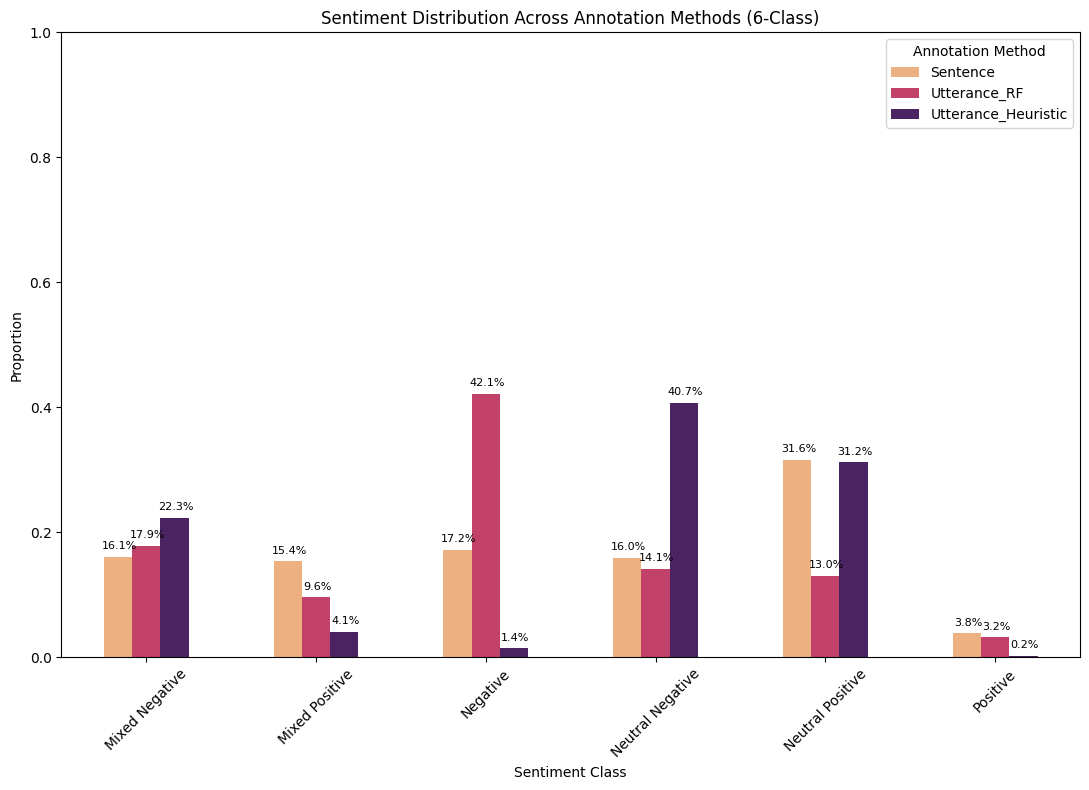

In [58]:
ax = labels_df.plot(kind='bar', figsize=(11, 8), rot=45, colormap='flare')
plt.title("Sentiment Distribution Across Annotation Methods (6-Class)")
plt.ylabel("Proportion")
plt.xlabel("Sentiment Class")
plt.legend(title="Annotation Method")
plt.ylim(0, 1)

# 5. Add percentage annotations
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(1, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./Figures/Distribution_6class.png', dpi=300)
plt.show()

## Sentiment distributions (3-class scale) for s-, u-, h-annotations
Plotting distributions of the sentiment (3-class schema), utilising proportions that each annotation category represents within the dataset to allow for a fair comparison
(normalizing value counts for individual category).


In [28]:
s_sentiment = sent['s_sentiment'].value_counts(normalize=True).sort_index()
u_sentiment = utt['u_sentiment'].value_counts(normalize=True).sort_index()
h_sentiment = utt['h_sentiment'].value_counts(normalize=True).sort_index()

print("Value counts for:", s_sentiment)
print("Value counts for:", u_sentiment)
print("Value counts for:", h_sentiment)

Value counts for: s_sentiment
Negative    0.332825
Neutral     0.475084
Positive    0.192091
Name: proportion, dtype: float64
Value counts for: u_sentiment
Negative    0.600008
Neutral     0.271938
Positive    0.128054
Name: proportion, dtype: float64
Value counts for: h_sentiment
Negative    0.237534
Neutral     0.719425
Positive    0.043040
Name: proportion, dtype: float64


In [29]:
sentiment_df = pd.DataFrame({
    'Sentence': s_sentiment, 
    'Utterance_RF': u_sentiment,
    'Utterance_Heuristic': h_sentiment, 
}).fillna(0)
sentiment_df

,Sentence,Utterance_RF,Utterance_Heuristic
Negative,0.332825,0.600008,0.237534
Neutral,0.475084,0.271938,0.719425
Positive,0.192091,0.128054,0.043040


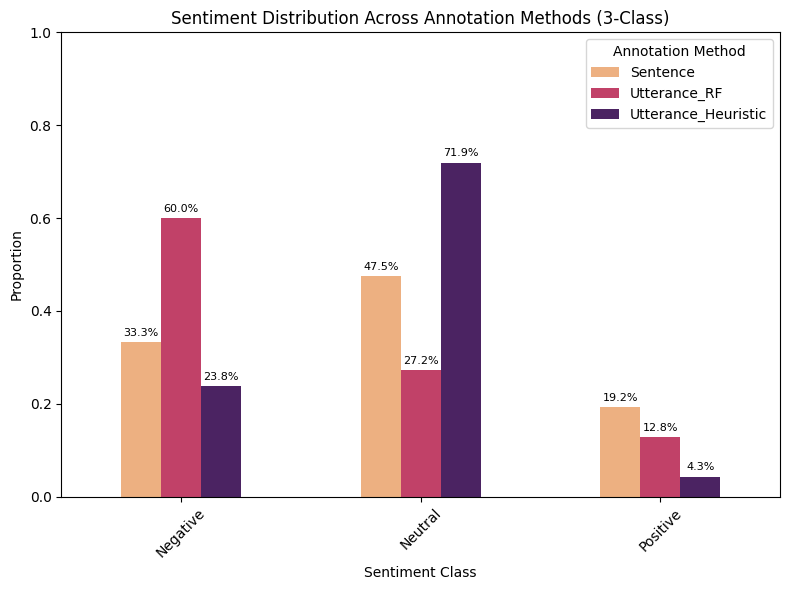

In [57]:
ax = sentiment_df.plot(kind='bar', figsize=(8,6), rot=45, colormap='flare')
plt.title("Sentiment Distribution Across Annotation Methods (3-Class)")
plt.ylabel("Proportion")
plt.xlabel("Sentiment Class")
plt.legend(title="Annotation Method")
plt.ylim(0, 1)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy= (bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points', 
                    ha='center', va='bottom', fontsize=8,
                    )
        
plt.tight_layout()
plt.savefig('./Figures/Distribution_3class.png', dpi=300)
plt.show()